## 1. We discussed two methods that are used for feature representation for text data. What are those methods and what are the main advantages and disadvantages of each one?
There are two common methods for text feature representation:

1. Bag-of-Words (BoW)
➤ What It Is:

The Bag-of-Words model transforms a collection of text documents into a matrix of word counts. It treats each document as a "bag" of individual words, ignoring grammar and word order, and focuses solely on whether known words occur in the document.

Each document is represented as a vector of term frequencies:

Rows = documents,
Columns = vocabulary (unique words across all documents),
Values = frequency of each word in the corresponding document

➤ Advantages:

Simple and Fast: Easy to implement and computationally efficient, especially for large corpora.
Works well for high-frequency keywords: Performs surprisingly well in classification tasks where word presence/absence matters more than context.
Easy to interpret: Each feature corresponds to an actual word, which makes the model easier to debug and understand.

➤ Disadvantages:

Ignores context and order: The same vector is generated whether the sentence is “the cat sat on the mat” or “the mat sat on the cat.”
High dimensionality: As vocabulary grows, the number of features increases significantly, leading to sparse data and memory inefficiency.
Equal importance to all words: Common words like “news,” “today,” or “said” may dominate without adding meaningful distinction unless removed as stopwords.

2. TF-IDF (Term Frequency-Inverse Document Frequency)
➤ What It Is:

TF-IDF builds on BoW but adds a statistical measure that evaluates how important a word is to a document in a collection. Instead of raw counts, it weighs terms by:

TF (Term Frequency): Frequency of a word in a document.
IDF (Inverse Document Frequency): Penalizes words that appear in many documents (less informative), and boosts words that are rare across the corpus (more informative).
The result is a score that highlights distinctive terms rather than just common ones.

➤ Advantages:

Reduces weight of common words: Prevents frequently occurring but uninformative words (like "the", "is", "said") from skewing the model.
Captures importance: Rewards unique terms, making it more suitable for topic detection and classification.
More robust for large corpora: Often leads to better performance in text mining, information retrieval, and document clustering.

➤ Disadvantages:

Still ignores word order and semantics: Like BoW, it doesn’t understand the context or meaning behind words.
Sensitive to rare words: May overemphasize very rare or misspelled words that appear once or twice.
Requires more computation: Because it calculates document-level statistics (IDF), it is more computationally expensive than BoW.

In [3]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/devsingh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df = pd.read_csv("HW11_News_Category_HuffPost_2012_2018_50k_cleaned.csv")
df = df[['short_description', 'category']].dropna()
df = df[df['short_description'].str.strip() != ""]
df.head(5)

,short_description,category
0,Resting is part of training. I've confirmed wh...,WELLNESS
1,Think of talking to yourself as a tool to coac...,WELLNESS
2,The clock is ticking for the United States to ...,WELLNESS
3,"If you want to be busy, keep trying to be perf...",WELLNESS
4,"First, the bad news: Soda bread, corned beef a...",WELLNESS


In [5]:
X = df['short_description']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def stem_text(text):
    tokens = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    stemmed = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return " ".join(stemmed)

# Apply stemming only to stemmed versions
X_train_stem = X_train.apply(stem_text)
X_test_stem = X_test.apply(stem_text)

In [11]:
def evaluate_model(dtm_train, dtm_test, y_train, y_test, model_label):
    model = MultinomialNB()
    model.fit(dtm_train, y_train)
    y_pred = model.predict(dtm_test)
    print(f"\n=== {model_label} ===")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    fig, ax = plt.subplots(figsize=(14, 14))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=ax, xticks_rotation=90, cmap='viridis', colorbar=False)
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)
    plt.title(f"Confusion Matrix – {model_label}", fontsize=13)
    plt.tight_layout()
    plt.show()


=== BoW - Unigrams, No Stemming ===
                precision    recall  f1-score   support

      BUSINESS       0.60      0.71      0.65       955
 ENTERTAINMENT       0.69      0.48      0.56       985
  FOOD & DRINK       0.76      0.69      0.72      1021
     PARENTING       0.51      0.69      0.59      1030
      POLITICS       0.70      0.59      0.64      1034
        SPORTS       0.82      0.70      0.76       995
STYLE & BEAUTY       0.73      0.72      0.73       986
        TRAVEL       0.68      0.69      0.68      1008
      WELLNESS       0.58      0.70      0.63      1009
    WORLD NEWS       0.72      0.69      0.71       977

      accuracy                           0.67     10000
     macro avg       0.68      0.67      0.67     10000
  weighted avg       0.68      0.67      0.67     10000



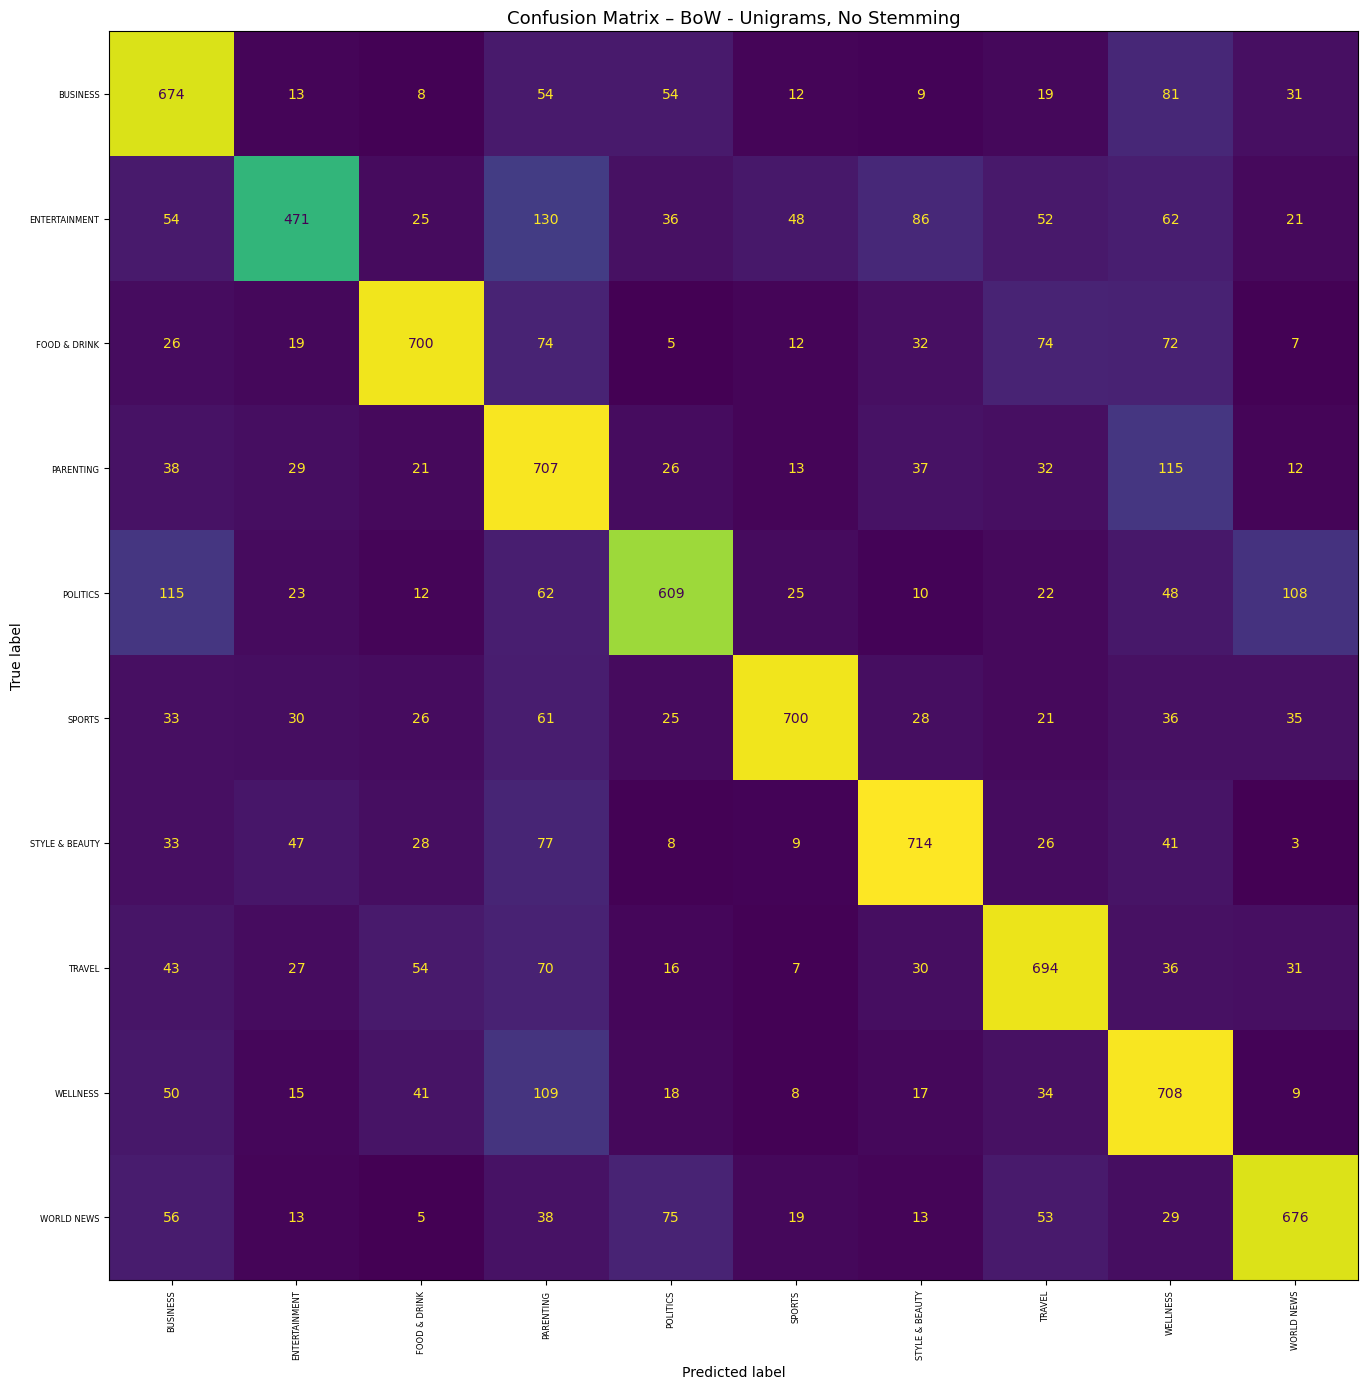


=== BoW - Unigrams, With Stemming ===
                precision    recall  f1-score   support

      BUSINESS       0.59      0.68      0.63       955
 ENTERTAINMENT       0.69      0.46      0.55       985
  FOOD & DRINK       0.77      0.68      0.72      1021
     PARENTING       0.51      0.68      0.58      1030
      POLITICS       0.69      0.60      0.65      1034
        SPORTS       0.83      0.67      0.74       995
STYLE & BEAUTY       0.72      0.72      0.72       986
        TRAVEL       0.67      0.70      0.68      1008
      WELLNESS       0.55      0.71      0.62      1009
    WORLD NEWS       0.72      0.69      0.71       977

      accuracy                           0.66     10000
     macro avg       0.68      0.66      0.66     10000
  weighted avg       0.68      0.66      0.66     10000



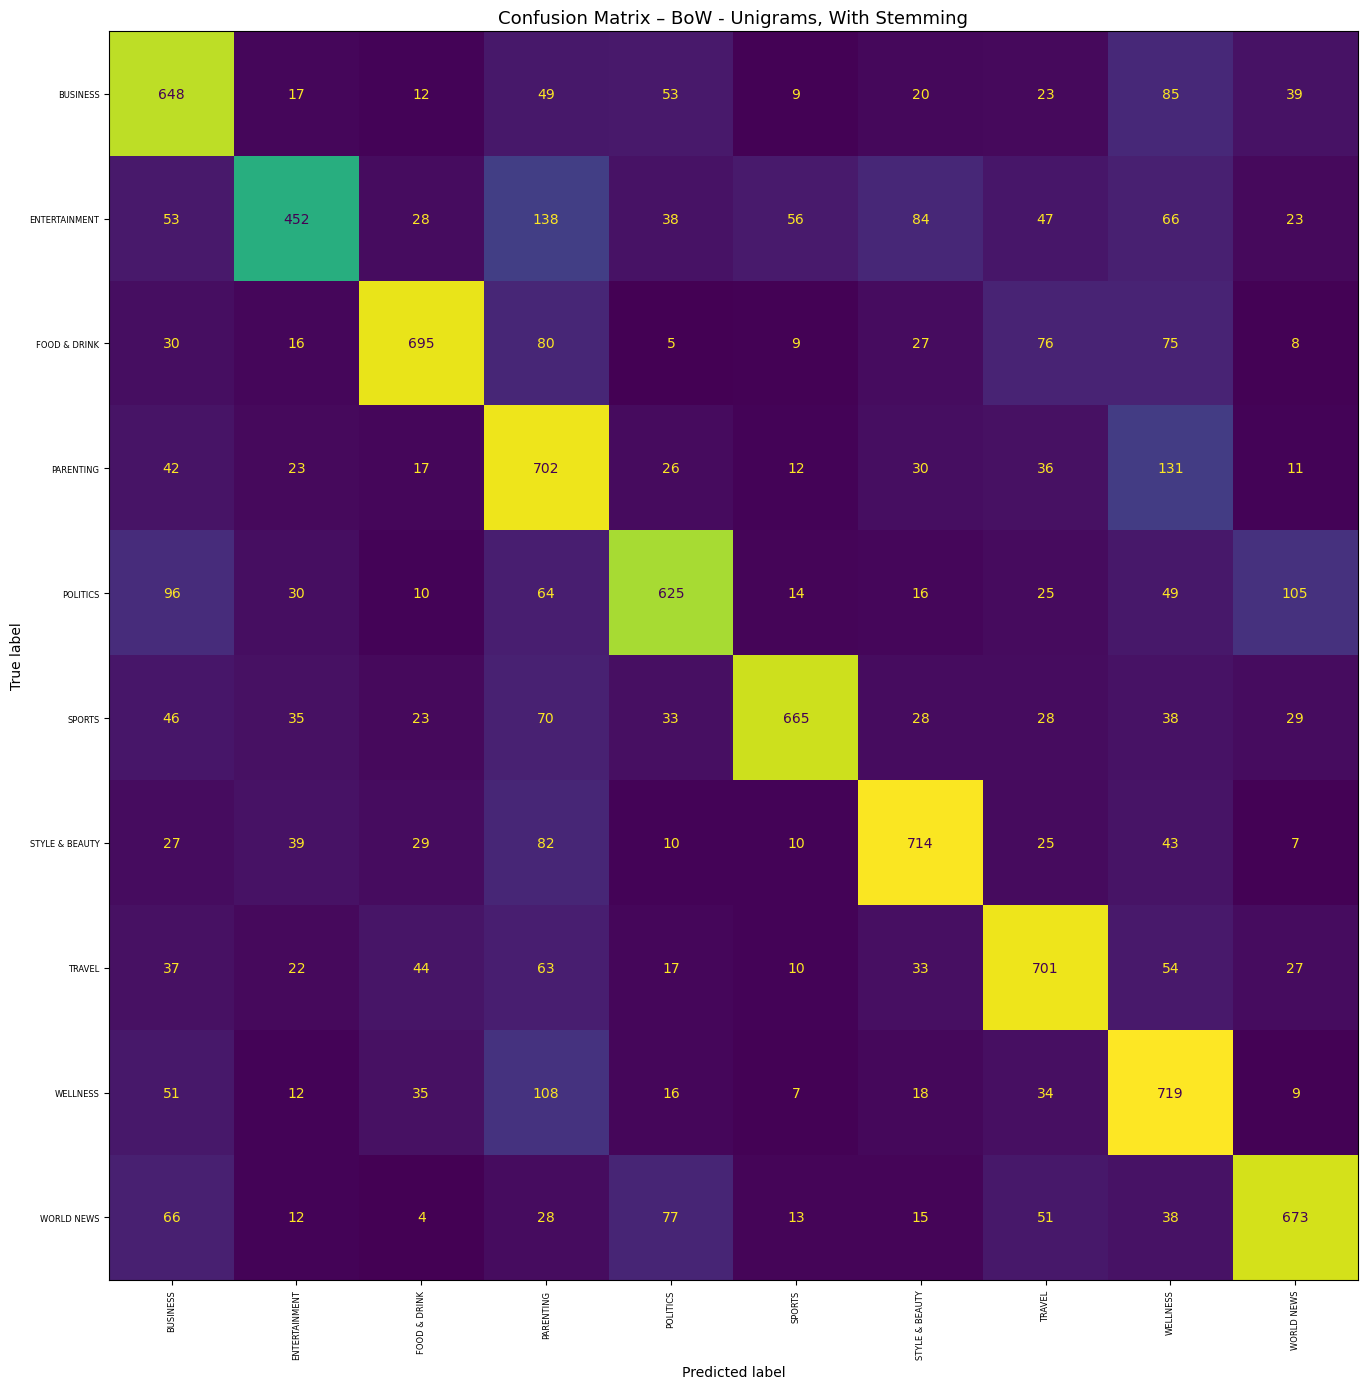


=== BoW - Bigrams ===
                precision    recall  f1-score   support

      BUSINESS       0.61      0.81      0.70       955
 ENTERTAINMENT       0.78      0.43      0.56       985
  FOOD & DRINK       0.82      0.62      0.71      1021
     PARENTING       0.52      0.70      0.59      1030
      POLITICS       0.76      0.58      0.66      1034
        SPORTS       0.88      0.79      0.83       995
STYLE & BEAUTY       0.74      0.73      0.73       986
        TRAVEL       0.64      0.73      0.68      1008
      WELLNESS       0.56      0.74      0.64      1009
    WORLD NEWS       0.75      0.70      0.72       977

      accuracy                           0.68     10000
     macro avg       0.71      0.68      0.68     10000
  weighted avg       0.71      0.68      0.68     10000



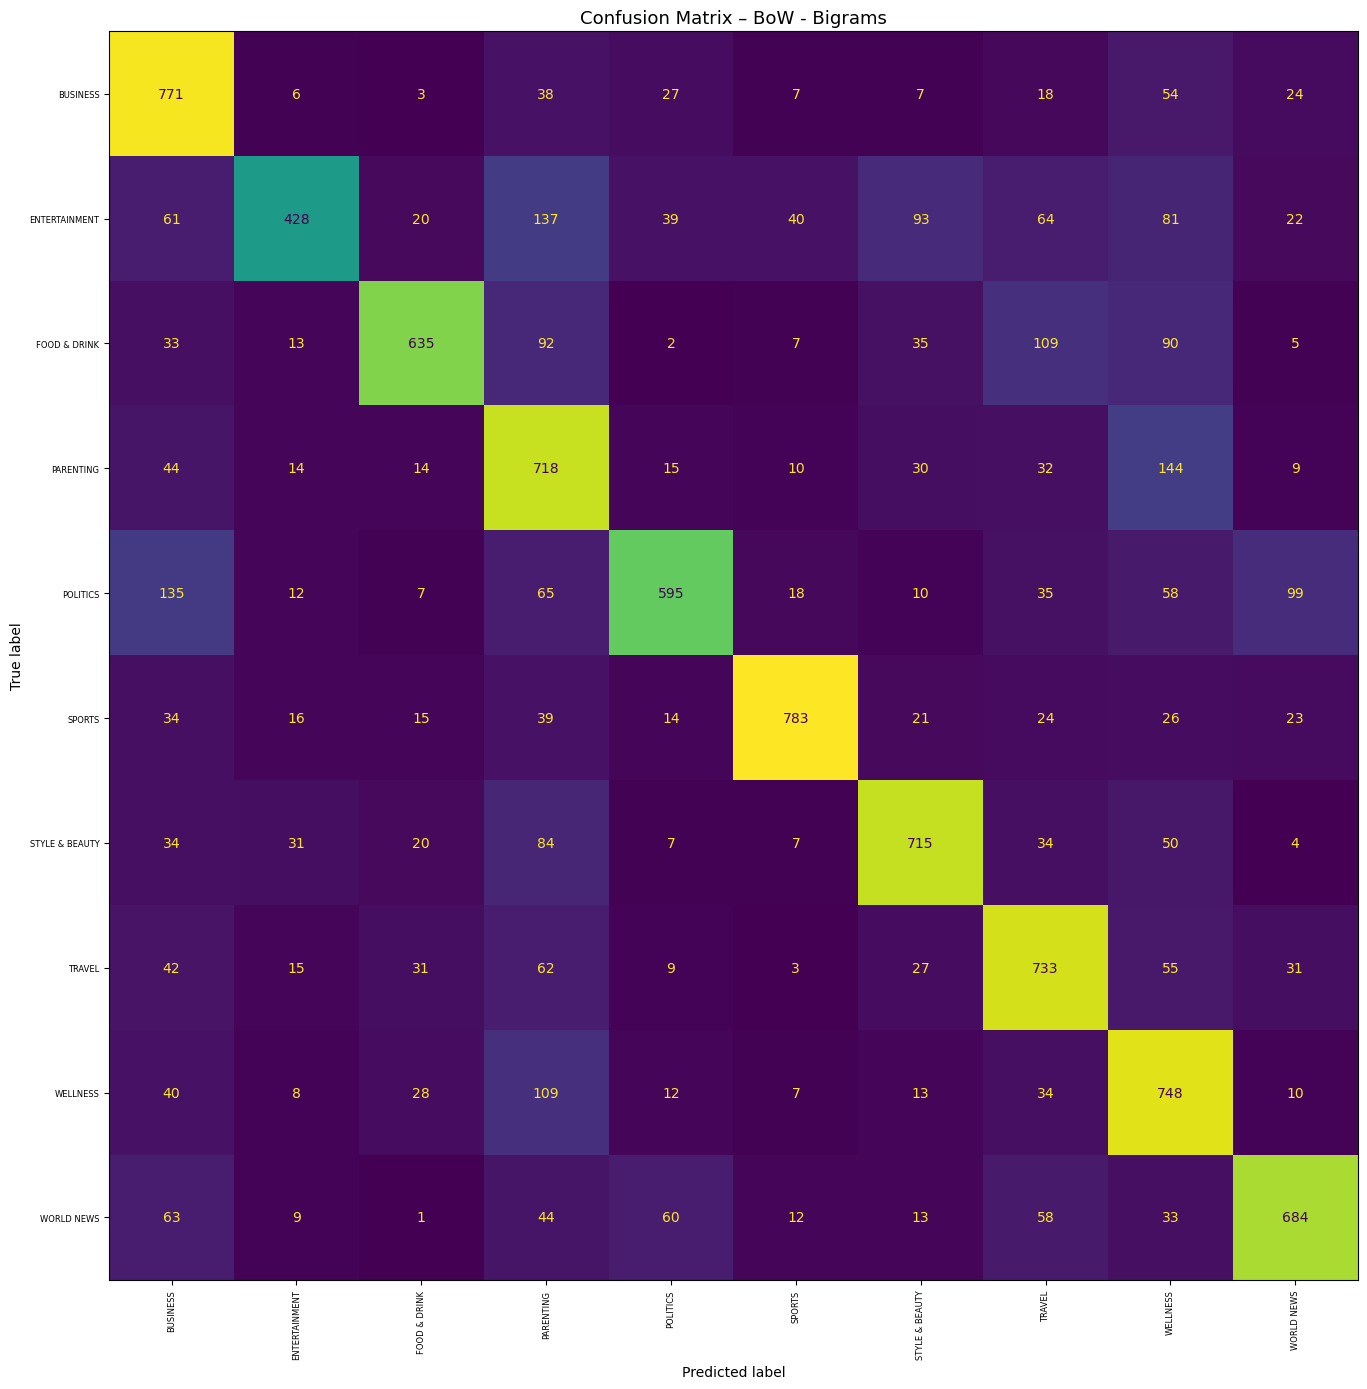

In [13]:
# === Q2a: Bag of Words ===
# (1) Unigrams, no stemming
bw1 = CountVectorizer(stop_words='english')
dtm_train1 = bw1.fit_transform(X_train)
dtm_test1 = bw1.transform(X_test)
evaluate_model(dtm_train1, dtm_test1, y_train, y_test, "BoW - Unigrams, No Stemming")

# (2) Unigrams + stemming
bw2 = CountVectorizer()
dtm_train2 = bw2.fit_transform(X_train_stem)
dtm_test2 = bw2.transform(X_test_stem)
evaluate_model(dtm_train2, dtm_test2, y_train, y_test, "BoW - Unigrams, With Stemming")

# (3) Bigrams + stopwords
bw3 = CountVectorizer(ngram_range=(1,2), stop_words='english')
dtm_train3 = bw3.fit_transform(X_train)
dtm_test3 = bw3.transform(X_test)
evaluate_model(dtm_train3, dtm_test3, y_train, y_test, "BoW - Bigrams")

## 2.a Conclusion: 
Using Bag of Words with stopword removal, stemming, and bigrams captured more meaningful word combinations and reduced noise, improving the model performance. Bigrams helped recognize context better compared to just unigrams. The best accuracy rate is 66.4%.


=== TF-IDF - Unigrams, No Stemming ===
                precision    recall  f1-score   support

      BUSINESS       0.60      0.72      0.65       955
 ENTERTAINMENT       0.72      0.49      0.59       985
  FOOD & DRINK       0.74      0.71      0.72      1021
     PARENTING       0.53      0.70      0.60      1030
      POLITICS       0.73      0.59      0.65      1034
        SPORTS       0.82      0.73      0.77       995
STYLE & BEAUTY       0.74      0.73      0.73       986
        TRAVEL       0.71      0.68      0.69      1008
      WELLNESS       0.59      0.69      0.64      1009
    WORLD NEWS       0.73      0.71      0.72       977

      accuracy                           0.68     10000
     macro avg       0.69      0.68      0.68     10000
  weighted avg       0.69      0.68      0.68     10000



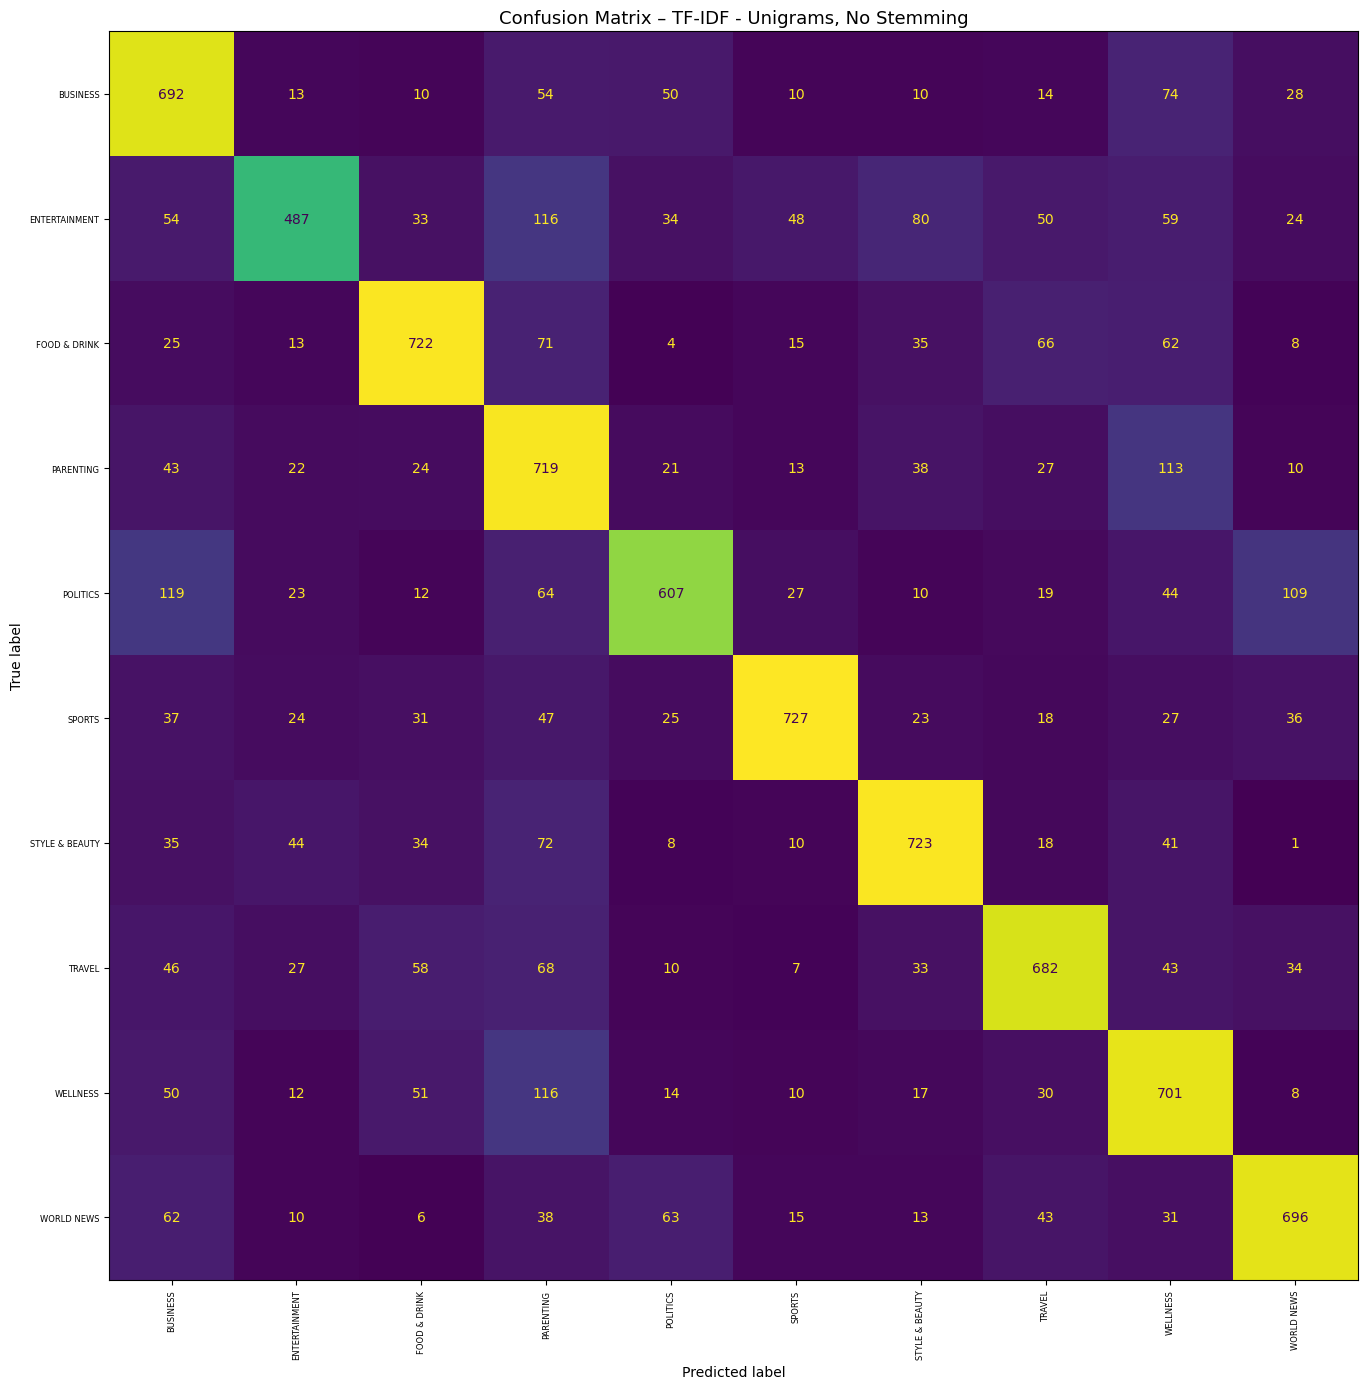


=== TF-IDF - Unigrams, With Stemming ===
                precision    recall  f1-score   support

      BUSINESS       0.59      0.70      0.64       955
 ENTERTAINMENT       0.72      0.45      0.56       985
  FOOD & DRINK       0.77      0.70      0.73      1021
     PARENTING       0.51      0.68      0.58      1030
      POLITICS       0.71      0.59      0.65      1034
        SPORTS       0.82      0.70      0.75       995
STYLE & BEAUTY       0.73      0.72      0.73       986
        TRAVEL       0.69      0.68      0.68      1008
      WELLNESS       0.55      0.72      0.62      1009
    WORLD NEWS       0.72      0.69      0.71       977

      accuracy                           0.66     10000
     macro avg       0.68      0.66      0.66     10000
  weighted avg       0.68      0.66      0.66     10000



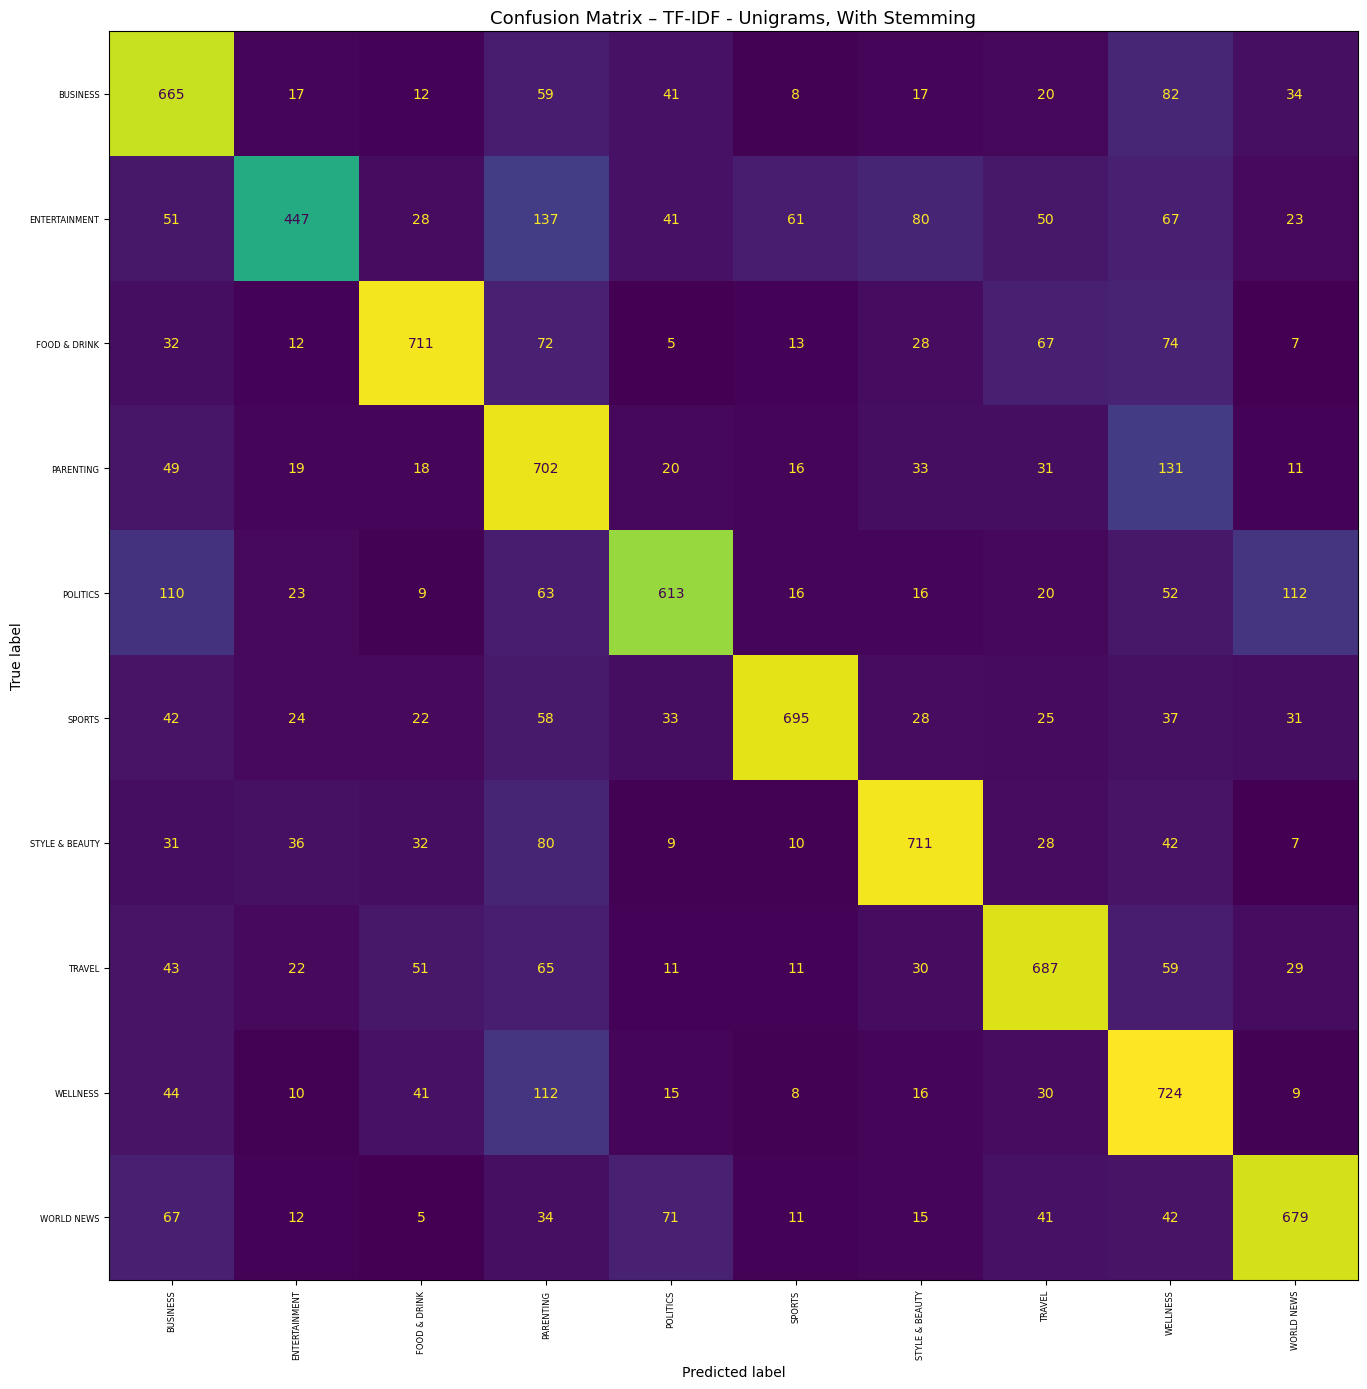


=== TF-IDF - Bigrams ===
                precision    recall  f1-score   support

      BUSINESS       0.61      0.81      0.70       955
 ENTERTAINMENT       0.75      0.49      0.59       985
  FOOD & DRINK       0.77      0.69      0.73      1021
     PARENTING       0.56      0.70      0.62      1030
      POLITICS       0.77      0.58      0.66      1034
        SPORTS       0.83      0.84      0.84       995
STYLE & BEAUTY       0.73      0.74      0.73       986
        TRAVEL       0.71      0.69      0.70      1008
      WELLNESS       0.59      0.70      0.65      1009
    WORLD NEWS       0.74      0.71      0.73       977

      accuracy                           0.70     10000
     macro avg       0.71      0.70      0.69     10000
  weighted avg       0.71      0.70      0.69     10000



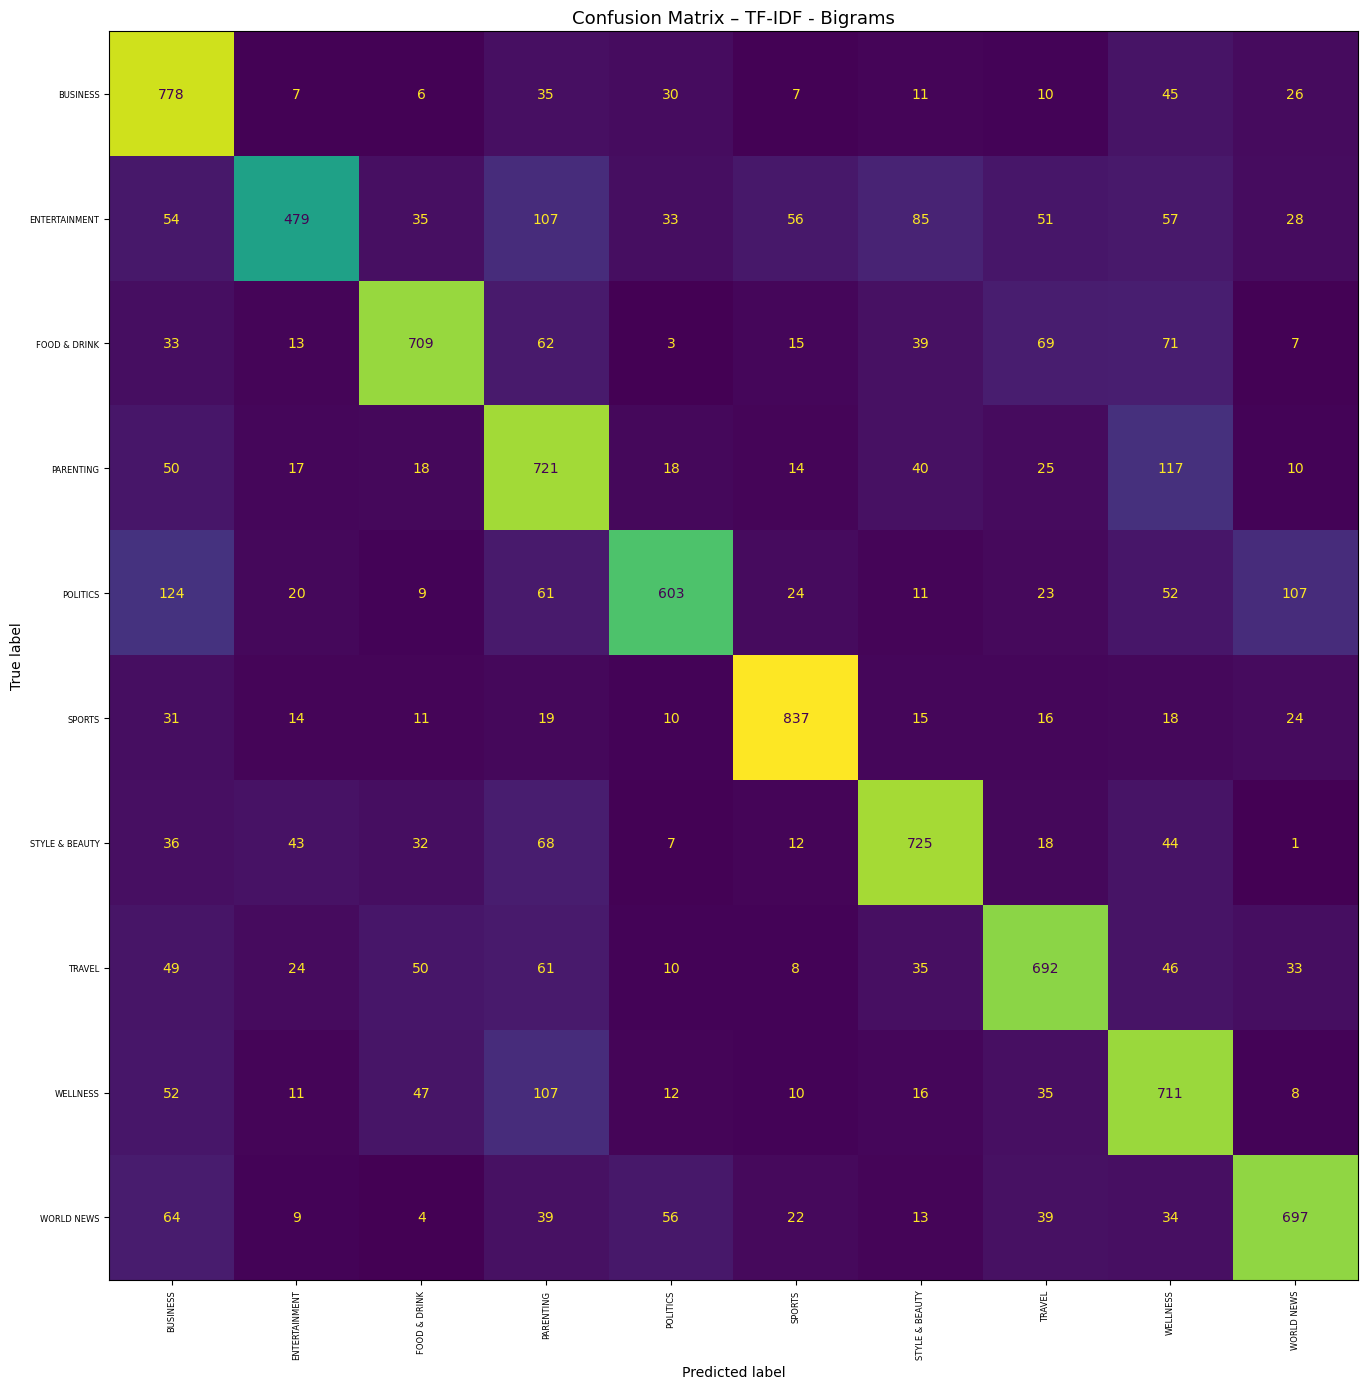

In [14]:
# === Q2b: TF-IDF ===
# (1) Unigrams, no stemming
tfidf1 = TfidfVectorizer(stop_words='english')
dtm_train1 = tfidf1.fit_transform(X_train)
dtm_test1 = tfidf1.transform(X_test)
evaluate_model(dtm_train1, dtm_test1, y_train, y_test, "TF-IDF - Unigrams, No Stemming")

# (2) Unigrams + stemming
tfidf2 = TfidfVectorizer()
dtm_train2 = tfidf2.fit_transform(X_train_stem)
dtm_test2 = tfidf2.transform(X_test_stem)
evaluate_model(dtm_train2, dtm_test2, y_train, y_test, "TF-IDF - Unigrams, With Stemming")

# (3) Bigrams + stopwords
tfidf3 = TfidfVectorizer(ngram_range=(1,2), stop_words='english')
dtm_train3 = tfidf3.fit_transform(X_train)
dtm_test3 = tfidf3.transform(X_test)
evaluate_model(dtm_train3, dtm_test3, y_train, y_test, "TF-IDF - Bigrams")

## 2.b Conclusion: 
TF-IDF worked slightly better than Bag of Words because it not only counted word frequencies but also gave lower weight to very common words across documents, making it more effective in identifying category-specific terms. The best accuracy rate is 68.1%.

=== Classification Report ===
                precision    recall  f1-score   support

      BUSINESS       0.75      0.86      0.80       955
 ENTERTAINMENT       0.89      0.76      0.82       985
  FOOD & DRINK       0.88      0.84      0.86      1021
     PARENTING       0.72      0.78      0.75      1030
      POLITICS       0.87      0.76      0.81      1034
        SPORTS       0.90      0.95      0.92       995
STYLE & BEAUTY       0.86      0.88      0.87       986
        TRAVEL       0.84      0.82      0.83      1008
      WELLNESS       0.75      0.76      0.75      1009
    WORLD NEWS       0.82      0.84      0.83       977

      accuracy                           0.82     10000
     macro avg       0.83      0.82      0.82     10000
  weighted avg       0.83      0.82      0.82     10000



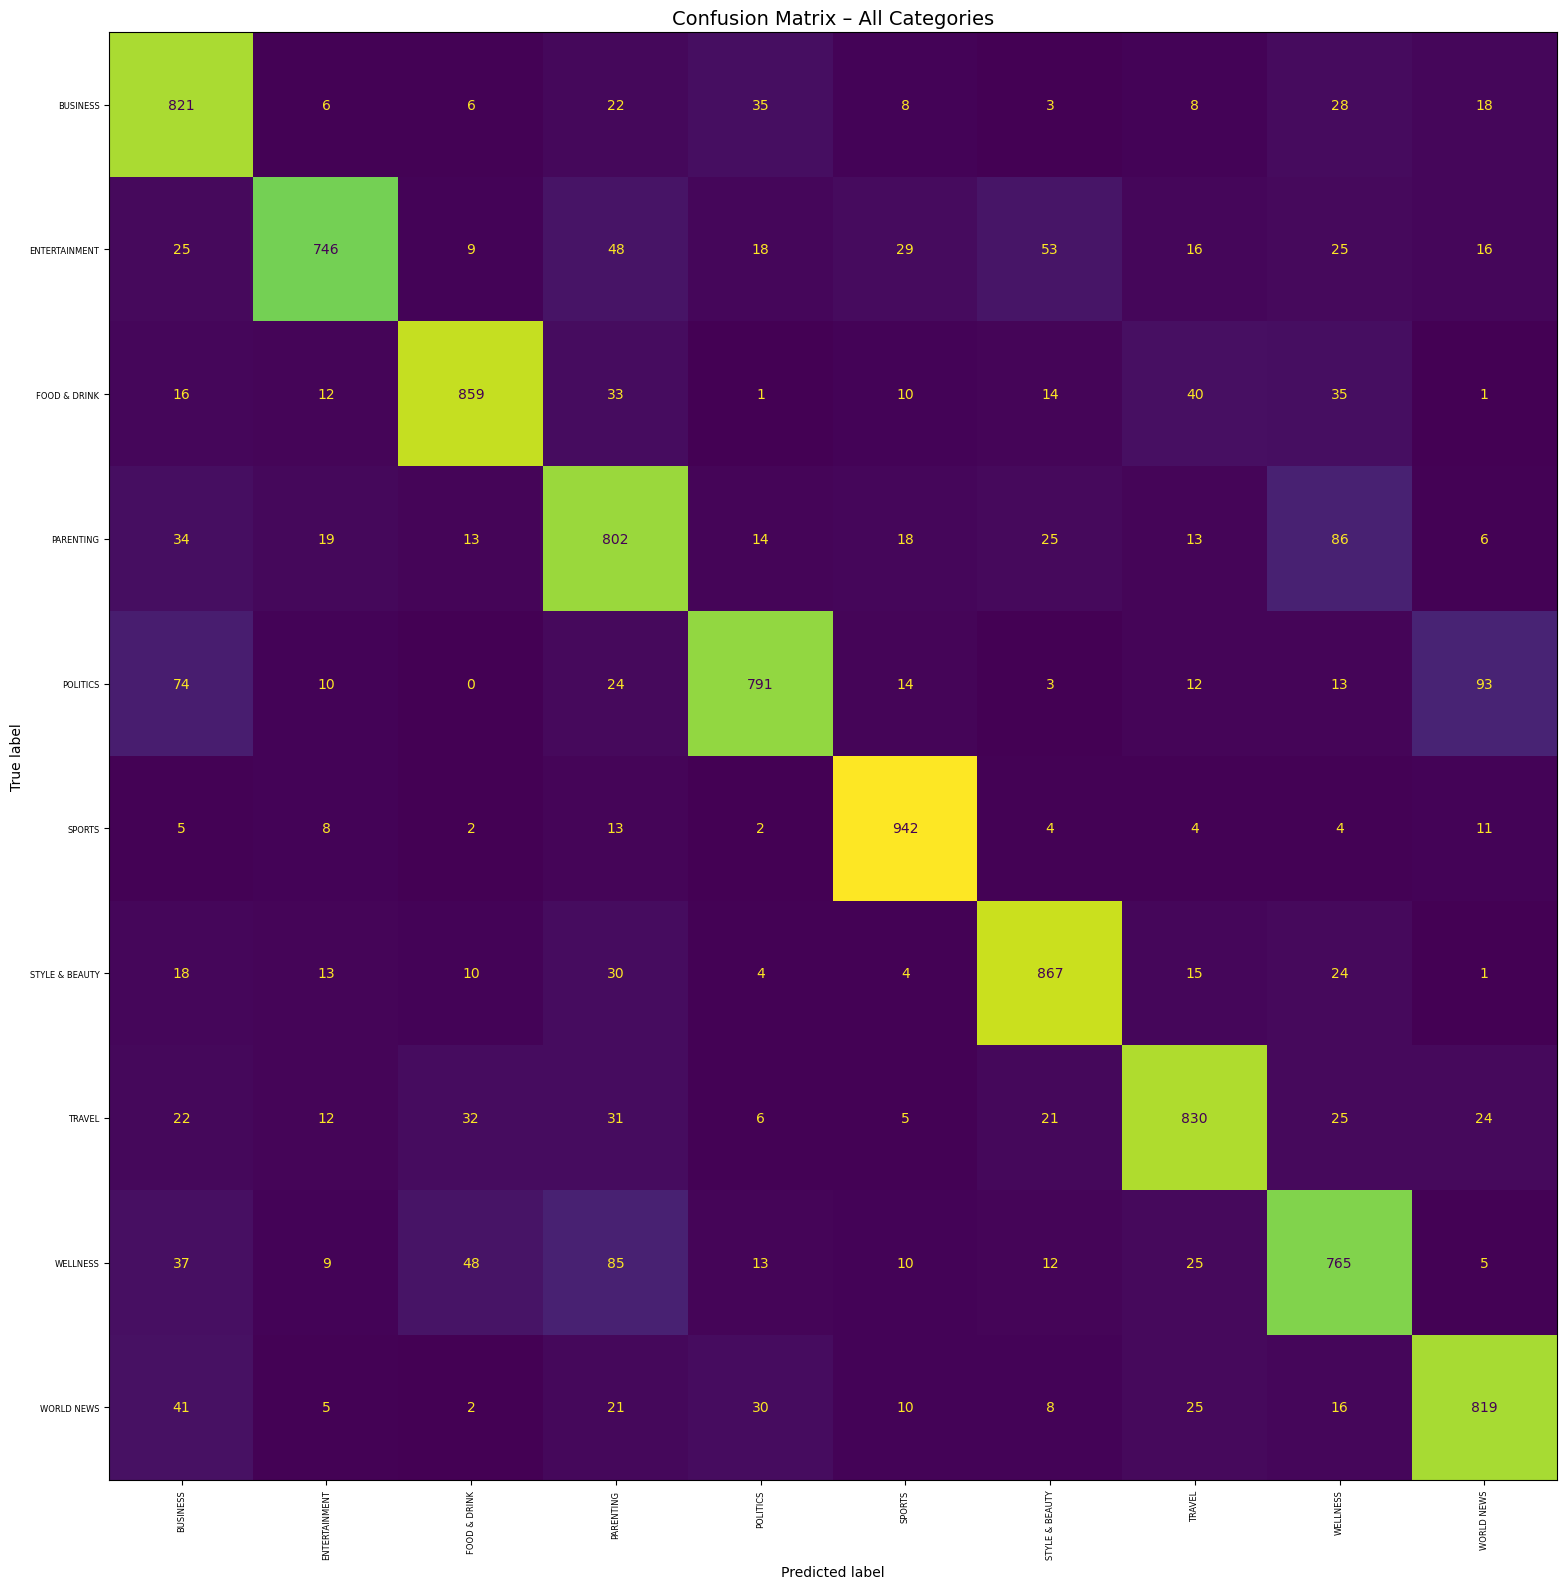

In [15]:
## Q2.c
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# === STEP 2: Load and Combine Data ===
df = pd.read_csv("HW11_News_Category_HuffPost_2012_2018_50k_cleaned.csv")

# Keep only needed columns and drop missing values
df = df[['short_description', 'headline', 'category']].dropna()
df = df[df['short_description'].str.strip() != ""]

# Combine short_description and headline
df['combined_text'] = df['short_description'] + " " + df['headline']

# === STEP 3: Split into Train and Test ===
X = df['combined_text']
y = df['category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === STEP 4: TF-IDF Vectorization with Bigrams ===
vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# === STEP 5: Train Naive Bayes Model ===
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)

# === STEP 6: Evaluation Metrics ===
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# === STEP 7: Confusion Matrix (Clean Display) ===
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

fig, ax = plt.subplots(figsize=(16, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, xticks_rotation=90, cmap='viridis', colorbar=False)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title("Confusion Matrix – All Categories", fontsize=14)
plt.tight_layout()
plt.show()

## 2.c Conclusion:
Including the headline provided additional useful context and important keywords that were not always present in the short description alone. As a result, the model could better distinguish between categories, improving overall classification accuracy by about 3.4% from 68.1% to 71.5%.